# **Beyond the Warehouse: Advanced Analytics with SQL in BigQuery**

## 0. Environment Setup

In [55]:
from google.cloud import bigquery
from google.cloud import bigquery_connection_v1 as bq_connection
from google.colab import auth
from google.cloud import resourcemanager_v3
import google.auth
import pandas as pd

auth.authenticate_user()
credentials, _ = google.auth.default()

PROJECT_ID = google.auth.default()[1]
RAW_DATASET_ID = "raw_thelook_ecommerce" # @param {"type":"string", "placeholder": "Enter the dataset naming convention where raw will be created"}
STAGING_DATASET_ID = "stg_thelook_ecommerce" # @param {"type":"string", "placeholder": "Enter the dataset naming convention where stg"}
LOCATION = "us" # @param {"type":"string", "placeholder": "Enter the location for the dataset"}
CONNECTION_NAME = "bq_vertex_conn" # @param {"type":"string", "placeholder": "Enter the BigQuery to Vertex AI connection Name"}
CONNECTION_ID = f"{PROJECT_ID}.{LOCATION}.{CONNECTION_NAME}"
rm_client = resourcemanager_v3.ProjectsClient()
project_name = f"projects/{PROJECT_ID}"
project_data = rm_client.get_project(name=project_name)
PROJECT_NUM = project_data.name.split("/")[1]

client = bigquery.Client(project=PROJECT_ID, location=LOCATION)

print(f"🚀 Demo configured for:")
print(f"   Project_ID: {PROJECT_ID}")
print(f"   Project_Num: {PROJECT_NUM}")
print(f"   Dataset: {RAW_DATASET_ID}")
print(f"   Dataset: {STAGING_DATASET_ID}")
print(f"   Location: {LOCATION}")
print(f"   Connection: {CONNECTION_NAME}")

# Creates a BigQuery to Vertex AI connection and grants it vertex ai user role
conn_client = bq_connection.ConnectionServiceClient()
request_path = conn_client.connection_path(PROJECT_ID, LOCATION, CONNECTION_NAME)
try:
    connection_info = conn_client.get_connection(name=request_path)
    print(f"Connection {CONNECTION_NAME} already exists.")
    service_account = connection_info.cloud_resource.service_account_id
except Exception:
    print(f"Creating connection {CONNECTION_NAME}...")
    !bq mk --connection \
        --location={LOCATION} \
        --project_id={PROJECT_ID} \
        --connection_type=CLOUD_RESOURCE \
        {CONNECTION_NAME}

    connection_info = conn_client.get_connection(name=request_path)
    service_account = connection_info.cloud_resource.service_account_id

print(f"Granting Vertex AI User role")
!gcloud projects add-iam-policy-binding {PROJECT_ID} \
    --member="serviceAccount:{service_account}" \
    --role="roles/aiplatform.user" \
    --condition=None > /dev/null 2>&1
print("ermissions granted.")

# Creates stg environment
dataset_ref = client.dataset(STAGING_DATASET_ID)
try:
    client.get_dataset(dataset_ref)
    print(f"Dataset {STAGING_DATASET_ID} already exists.")
except:
    dataset = bigquery.Dataset(dataset_ref)
    dataset.location = LOCATION
    client.create_dataset(dataset)
    print(f"Created dataset {STAGING_DATASET_ID}.")
    THELOOK_ECOMM = "bigquery-public-data.thelook_ecommerce"
    try:
        source_tables = client.list_tables(THELOOK_ECOMM)

        for table in source_tables:
            table_id = table.table_id
            source_table_ref = f"{THELOOK_ECOMM}.{table_id}"
            dest_table_ref = f"{PROJECT_ID}.{STAGING_DATASET_ID}.{table_id}"

            if table_id == "products":
                    create_products_sql = f"""
                        CREATE OR REPLACE TABLE `{dest_table_ref}` AS
                        SELECT
                            id,
                            cost,
                            category,
                            name,
                            AI.GENERATE(('Give a short, one paragraph description of ', name)).result AS description,
                            brand,
                            retail_price,
                            department,
                            sku,
                            distribution_center_id
                        FROM `{source_table_ref}`
                        """
                    client.query(create_products_sql).result()
                    print(" Products Description Generated with AI.")

            else:
                print(f"Copying table: {table_id}...", end=" ")
                job_config = bigquery.CopyJobConfig()
                job_config.write_disposition = "WRITE_TRUNCATE"
                copy_job = client.copy_table(source_table_ref, dest_table_ref, job_config=job_config)
                copy_job.result()
                print("Done.")

        print(f"\nAll tables prepared in {STAGING_DATASET_ID}.")
    except Exception as e:
        print(f"\n Error preparing tables: {str(e)}")

# Creates raw environment
dataset_ref = client.dataset(RAW_DATASET_ID)
try:
    client.get_dataset(dataset_ref)
    print(f"Dataset {RAW_DATASET_ID} already exists.")
except:
    dataset = bigquery.Dataset(dataset_ref)
    dataset.location = LOCATION
    client.create_dataset(dataset)
    print(f"Created dataset {RAW_DATASET_ID}.")
    create_raw_table_sql = f"""
        CREATE TABLE IF NOT EXISTS `{PROJECT_ID}.{RAW_DATASET_ID}.user_orders` AS
        SELECT
          TO_JSON(STRUCT(
            u.id AS user_id,
            u.email,
            u.age,
            (SELECT ARRAY_AGG(STRUCT(o.order_id, o.status, o.created_at))
             FROM `bigquery-public-data.thelook_ecommerce.orders` o
             WHERE o.user_id = u.id) AS orders
          )) AS json_payload
        FROM `bigquery-public-data.thelook_ecommerce.users` u
    """
    try:
        job = client.query(create_raw_table_sql)
        job.result()
        print(f"Table `{RAW_DATASET_ID}.user_orders` created successfully.")
    except Exception as e:
        print(f"Error creating raw table: {str(e)}")

# Insert some synthetic diversity to user_orders
insert_profile_sql = f"""
    INSERT INTO `{PROJECT_ID}.{RAW_DATASET_ID}.user_orders` (json_payload)
    VALUES (
      TO_JSON(STRUCT(
        888001 AS user_id,
        'Organic' AS traffic_source,
        STRUCT(
            'Jane' AS first_name,
            'Doe' AS last_name,
            'F' AS gender
        ) AS personal_info,
        STRUCT(
            '123 Cloud Way' AS street_address,
            'Seattle' AS city,
            'WA' AS state,
            '98109' AS postal_code,
            'USA' AS country,
            STRUCT(47.6062 AS latitude, -122.3321 AS longitude) AS coordinates
        ) AS location
      ))
    )
"""

try:
    client.query(insert_profile_sql).result()
    print("Profile inserted.")
except Exception as e:
    print(f"\nError inserting synthetic data: {str(e)}")

insert_logistics_sql = f"""
    INSERT INTO `{PROJECT_ID}.{RAW_DATASET_ID}.user_orders` (json_payload)
    VALUES (
      TO_JSON(STRUCT(
        555001 AS order_id,
        888001 AS user_id,
        'Shipped' AS status,
        3 AS num_of_item,
        STRUCT(
            TIMESTAMP('2024-03-01 08:00:00 UTC') AS placed,
            TIMESTAMP('2024-03-02 14:30:00 UTC') AS shipped,
            CAST(NULL AS TIMESTAMP) AS delivered,
            CAST(NULL AS TIMESTAMP) AS returned
        ) AS timeline
      ))
    )
"""

try:
    client.query(insert_logistics_sql).result()
    print("Finished setup, Lets GO!")
except Exception as e:
    print(f"\nError inserting synthetic data: {str(e)}")

🚀 Demo configured for:
   Project_ID: pluri-poc
   Project_Num: 154787189845
   Dataset: raw_thelook_ecommerce
   Dataset: stg_thelook_ecommerce
   Location: us
   Connection: bq_vertex_conn
Creating connection bq_vertex_conn...
Connection 154787189845.us.bq_vertex_conn successfully created
Granting Vertex AI User role
ermissions granted.
Created dataset stg_thelook_ecommerce.
Copying table: distribution_centers... Done.
Copying table: events... Done.
Copying table: inventory_items... Done.
Copying table: order_items... Done.
Copying table: orders... Done.
 Products Description Generated with AI.
Copying table: thelook_ecommerce-table... Done.
Copying table: users... Done.

All tables prepared in stg_thelook_ecommerce.
Created dataset raw_thelook_ecommerce.
Table `raw_thelook_ecommerce.user_orders` created successfully.
Profile inserted.
Finished setup, Lets GO!


## 1. Ingestion & Discovery


### Schema-on-read

In [56]:
query = f"""
SELECT
    DISTINCT(JSON_KEYS(json_payload)) AS keys
FROM
    `{PROJECT_ID}.{RAW_DATASET_ID}.user_orders`
"""

df = client.query(query).to_dataframe()
display(df)

,keys
0,"[location, location.city, location.coordinates..."
1,"[num_of_item, order_id, status, timeline, time..."
2,"[age, email, orders, user_id]"


In [57]:
query = f"""
SELECT
  JSON_VALUE(json_payload, '$.user_id') AS user_id,
  JSON_VALUE(json_payload, '$.age') AS age,
  JSON_VALUE(json_payload, '$.email') AS email,
  JSON_QUERY(json_payload, '$.orders') AS orders_array_as_json_string,
  JSON_QUERY_ARRAY(json_payload, '$.orders') AS orders_as_native_array
FROM {PROJECT_ID}.{RAW_DATASET_ID}.user_orders
LIMIT 10;
"""

df = client.query(query).to_dataframe()
display(df)

,user_id,age,email,orders_array_as_json_string,orders_as_native_array
0,888001,None,None,None,[]
1,888001,None,None,None,[]
2,9259,12,christopherwilliams@example.com,"[{""created_at"":""2025-07-01T12:52:00Z"",""order_i...","[{""created_at"":""2025-07-01T12:52:00Z"",""order_i..."
3,43632,12,georgehicks@example.org,null,[]
4,22811,12,rodneypeterson@example.com,"[{""created_at"":""2022-12-05T09:48:00Z"",""order_i...","[{""created_at"":""2022-12-05T09:48:00Z"",""order_i..."
5,11174,12,jessicaguerra@example.org,"[{""created_at"":""2024-09-06T18:12:00Z"",""order_i...","[{""created_at"":""2024-09-06T18:12:00Z"",""order_i..."
6,7466,12,tammyleonard@example.org,"[{""created_at"":""2023-11-11T12:09:00Z"",""order_i...","[{""created_at"":""2023-11-11T12:09:00Z"",""order_i..."
7,68398,12,alecmoore@example.com,"[{""created_at"":""2020-09-13T11:30:00Z"",""order_i...","[{""created_at"":""2020-09-13T11:30:00Z"",""order_i..."
8,51290,12,samuelwilliams@example.com,"[{""created_at"":""2023-06-16T12:35:00Z"",""order_i...","[{""created_at"":""2023-06-16T12:35:00Z"",""order_i..."
9,88486,12,danielcruz@example.org,"[{""created_at"":""2025-10-02T14:02:00Z"",""order_i...","[{""created_at"":""2025-10-02T14:02:00Z"",""order_i..."


**Architectural Implication:**
This demonstrates the true power of "schema-on-read." BigQuery doesn't force us into a rigid schema. We can ingest raw, schema-less JSON, discover its structure using JSON_KEYS, and build a transformation pipeline (SELECT JSON_VALUE(...) FROM...) all in SQL after the data has already landed. The warehouse becomes its own ETL tool.

**Links to documentation**:


*   JSON functions in BigQuery: https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/json_functions



### Searching the Data

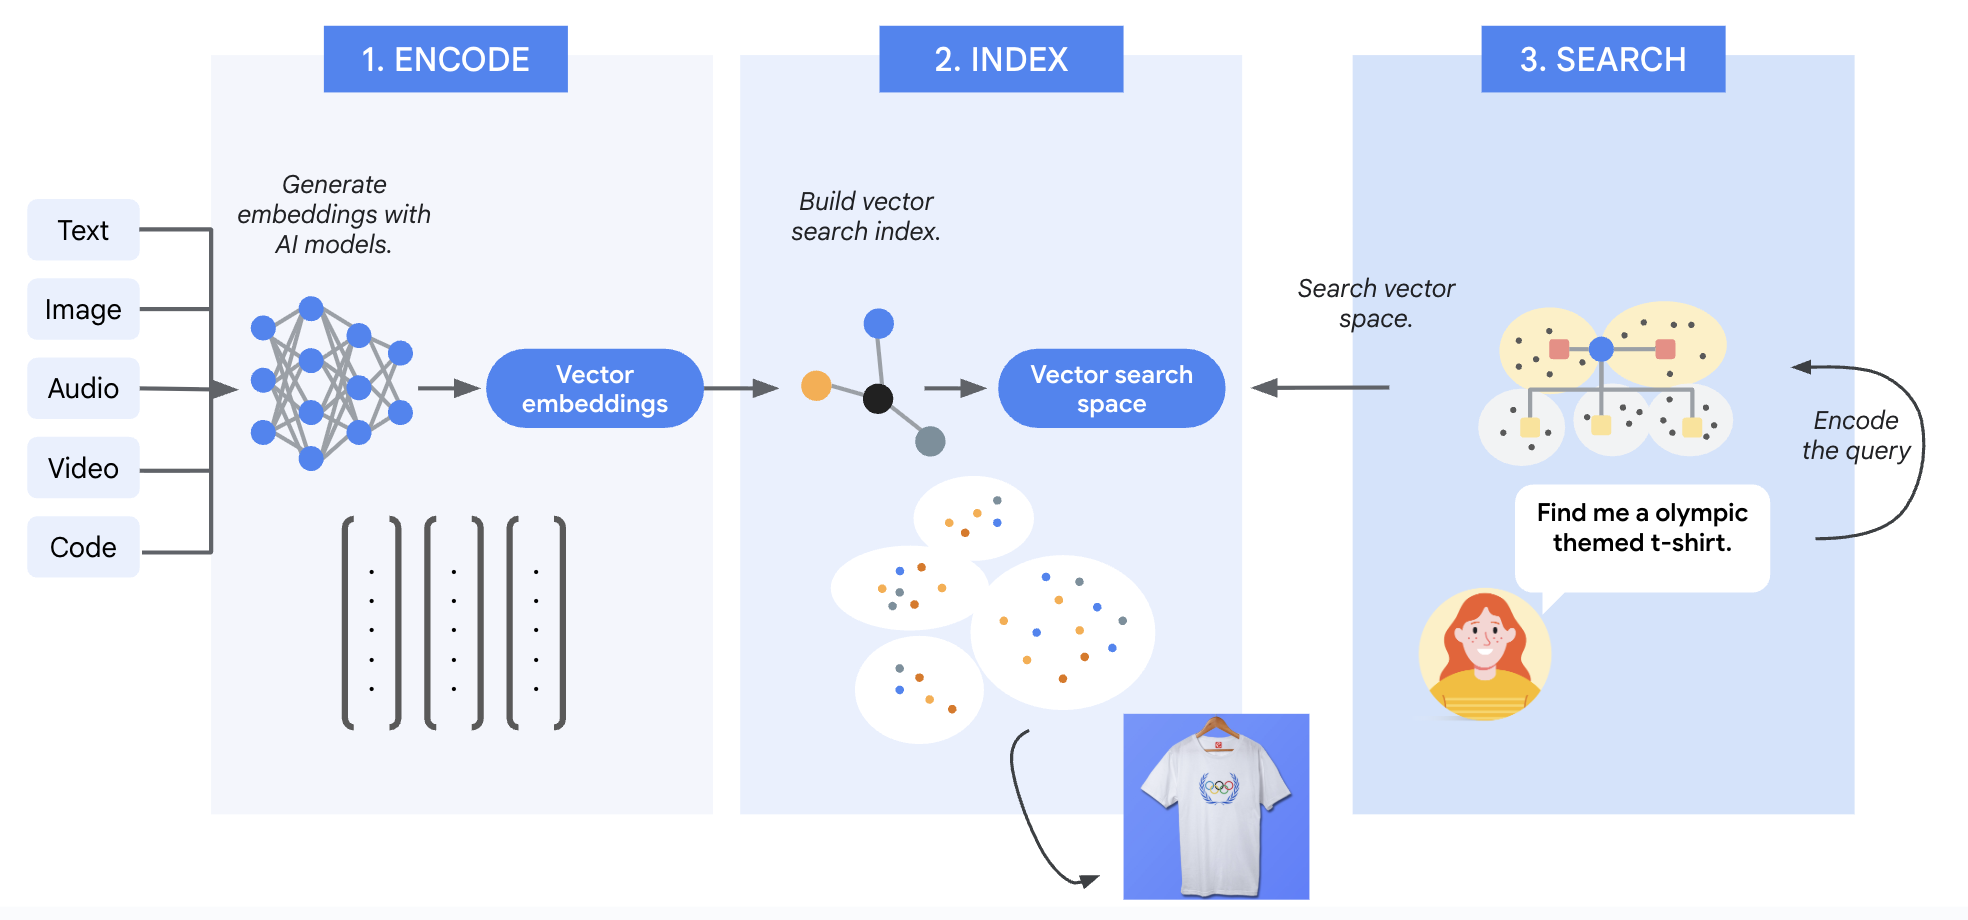

Setup the remote model

In [58]:
create_model_sql = f"""
CREATE MODEL IF NOT EXISTS `{PROJECT_ID}.{STAGING_DATASET_ID}.embedding_model`
REMOTE WITH CONNECTION `{CONNECTION_ID}`
OPTIONS (ENDPOINT = 'gemini-embedding-001');
"""

job = client.query(create_model_sql)
job.result()
print(f"Model created in {PROJECT_ID}.{STAGING_DATASET_ID}")

Model created in pluri-poc.stg_thelook_ecommerce


Generate and Materialize the Embeddings

In [59]:
embedding_sql = f"""
CREATE TABLE IF NOT EXISTS `{PROJECT_ID}.{STAGING_DATASET_ID}.products_embeddings` AS
SELECT * FROM (
  SELECT
    * EXCEPT(ml_generate_embedding_result),
    ml_generate_embedding_result AS embedding
  FROM ML.GENERATE_EMBEDDING(
    MODEL `{PROJECT_ID}.{STAGING_DATASET_ID}.embedding_model`,
    (
      SELECT
        *,
        CONCAT('Name: ', name,  '. Category: ', category, '. Brand: ', brand, '. Description: ', IFNULL(description, '')) AS content
      FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.products`
      WHERE name IS NOT NULL
    )
  )
)
WHERE ARRAY_LENGTH(embedding) > 0;
"""

job = client.query(embedding_sql)
job.result()
print("Embeddings generated.")

Embeddings generated.


Create a Vector Index

In [60]:
vector_index = f"""
CREATE VECTOR INDEX IF NOT EXISTS `product_embedding_index_gemini`
ON `{PROJECT_ID}.{STAGING_DATASET_ID}.products_embeddings`(embedding)
OPTIONS(distance_type='COSINE', index_type='IVF');
"""

job = client.query(vector_index)
job.result()
print("Vector index created")

Vector index created


Create search index

In [61]:
full_text_index = f"""
CREATE SEARCH INDEX IF NOT EXISTS demo_product_index
ON `{PROJECT_ID}.{STAGING_DATASET_ID}.products`(name, category, brand, description);
"""

job = client.query(full_text_index)
job.result()
print("Full-text index created")

Full-text index created


Run Hybrid Search

In [62]:
from typing import List, Dict

def hybrid_search(current_category: str, user_query: str):

    KEYWORD_QUERY = f"""
        SELECT id, name, description, cost
        FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.products_embeddings`
        WHERE category = '{current_category}'
          AND SEARCH((name, description), '{user_query}')
        LIMIT 10
    """
    keyword_results = list(client.query(KEYWORD_QUERY).result())

    keyword_map = {row.id: row for row in keyword_results}
    keyword_ids = set(keyword_map.keys())

    VECTOR_QUERY = f"""
        SELECT base.id, base.name, base.description, base.cost
        FROM VECTOR_SEARCH(
            (SELECT * FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.products_embeddings`
             WHERE category = '{current_category}'),
            'embedding',
            (
                SELECT ml_generate_embedding_result AS embed
                FROM ML.GENERATE_EMBEDDING(
                    MODEL `{PROJECT_ID}.{STAGING_DATASET_ID}.embedding_model`,
                    (SELECT '{user_query}' AS content)
                )
            ),
            top_k => 10,
            distance_type => 'COSINE'
        )
    """
    vector_results = list(client.query(VECTOR_QUERY).result())

    vector_map = {row.id: row for row in vector_results}
    vector_ids = set(vector_map.keys())

    hybrid_ids = keyword_ids.intersection(vector_ids)
    vector_only_ids = vector_ids - keyword_ids
    keyword_only_ids = keyword_ids - vector_ids

    # -- Bucket 1: The Semantic Wins --
    print(f"🧠 Semantic discoveries (missed by full-text search):")
    if not vector_only_ids:
        print("   (None)")
    for pid in vector_only_ids:
        prod = vector_map[pid]
        print(f"   • {prod.name} (${prod.cost})")
        # Optional: Print reasoning (e.g. 'Description didn't contain exact keyword')

    print("\n" + "-"*40 + "\n")

    # -- Bucket 2: The Precision Wins --
    print(f"🔍 Precision matches (missed by vector search):")
    if not keyword_only_ids:
        print("   (None)")
    for pid in keyword_only_ids:
        prod = keyword_map[pid]
        print(f"   • {prod.name} (${prod.cost})")

    print("\n" + "-"*40 + "\n")

    # -- Bucket 3: The High Confidence --
    print(f"⚡ Hybrid results (both engines found these):")
    if not hybrid_ids:
        print("   (None)")
    for pid in hybrid_ids:
        prod = keyword_map[pid] # Data is same in both
        print(f"   • {prod.name}")

cat = "Swim"
query = "drawstring"

hybrid_search(cat, query)

🧠 Semantic discoveries (missed by full-text search):
   • Relaxed Boardshort Short ($24.115500097163025)
   • Burnside Men's Wring Boardshort ($20.262000063434243)
   • Lacoste Drawstring Vertical Logo Swim Trunk ($55.08000016212464)
   • Calvin Klein Men's Voltage Stripe Drawstring Swim Short ($47.7300002425909)
   • Bottoms Out Men's Stripe Swim Short ($19.46350985771209)
   • Elan Gauzes Pants ($31.416000083088875)
   • Toes on the Nose Men's T-Street Boardshort ($37.35200007259846)
   • Claudette Drawstring Pant Swimwear Bikini Bottom ($12.800000071525574)
   • Womens Relaxed Drawstring Mesh Beach Pants With Color Options ($6.407100328297914)
   • Rusty Men's Undertow Boardshort ($23.078250518331306)

----------------------------------------

🔍 Precision matches (missed by vector search):
   • Gotcha Men's Large Scale Boardshort ($13.975000008940697)
   • parke & ronen Men's Microfiber Print Swim Short ($67.72500034421681)
   • Calvin Klein Men's Bermuda Swim Short ($43.66000012680

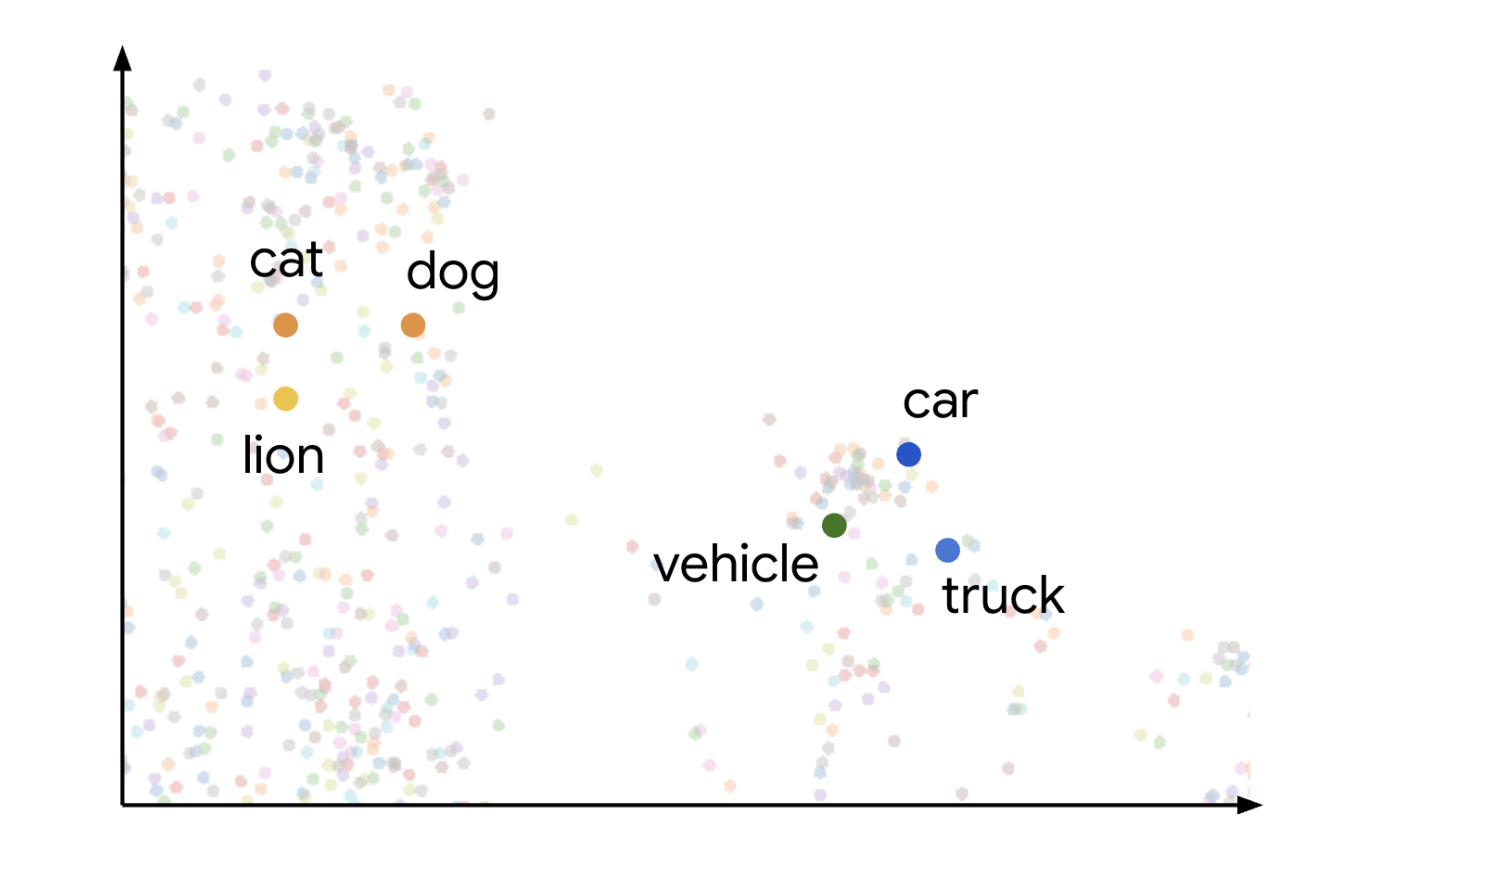

**Architectural Implication:**
We have just decoupled the search problem from the database problem. Analysts no longer need to export data to a separate, expensive system like Elasticsearch just for text search or Pincone for semantic search. They can now run federated queries that combine structured and unstructured data in a single, high-performance SQL query.

**Links to documentation:**


* Search functions in BigQuery: https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/search_functions#search
* Vector Search: https://docs.cloud.google.com/bigquery/docs/vector-search-intro
* Manage vector indexes: https://docs.cloud.google.com/bigquery/docs/vector-index
* Choose an embeddings task type: https://docs.cloud.google.com/vertex-ai/generative-ai/docs/embeddings/task-types


## 2. Real-Time Aggregations



In [63]:
from functools import wraps
import time

def bigquery_job_param(func):
    """
    Decorator that executes a BigQuery job (or a function that returns a QueryJob
    or DataFrame) and logs the job statistics.
    """
    @wraps(func)
    def wrapper(*args, **kwargs):

        sql_query = func(*args, **kwargs)
        query_job = client.query(sql_query)
        start_time = time.time()

        try:
            results = query_job.result()
        except Exception as e:
            print(f"ERROR: Query failed. Details:\n{e}")
            raise
        end_time = time.time()

        print("\n--- Job Execution Details ---")
        print(f"**Wall Time (Function):** {end_time - start_time:.2f} seconds")

        bytes_processed = query_job.total_bytes_processed
        if bytes_processed is not None:
            gb_processed = bytes_processed / (1024**3)
            print(f"**Data Processed:** {gb_processed:.2f} GB")

        if query_job.slot_millis:
            slot_hours = query_job.slot_millis / (1000 * 60 * 60)
            print(f"**Slot-Time Consumed:** {slot_hours:.4f} slot-hours")

        print(f"**Result Served from Cache:** {query_job.cache_hit}")
        print("-----------------------------------\n")

        return results.to_dataframe()

    return wrapper

In [64]:
@bigquery_job_param
def precise_count():
    return f"""
            SELECT
              'Precise Count' AS method,
              COUNT(DISTINCT session_id) AS distinct_sessions
            FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.events` """


precise_count = precise_count()
precise_c = precise_count['distinct_sessions'].iloc[0]
precise_count.head()


--- Job Execution Details ---
**Wall Time (Function):** 1.95 seconds
**Data Processed:** 0.09 GB
**Slot-Time Consumed:** 0.0023 slot-hours
**Result Served from Cache:** False
-----------------------------------



,method,distinct_sessions
0,Precise Count,680879


In [65]:
@bigquery_job_param
def approx_count():
    return f"""
            SELECT
              'Approximate Count' AS method,
              APPROX_COUNT_DISTINCT(session_id) as approx_distinct_sessions
            FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.events`"""


approx_count = approx_count()
approx_c = approx_count['approx_distinct_sessions'].iloc[0]
approx_count.head()


--- Job Execution Details ---
**Wall Time (Function):** 0.15 seconds
**Data Processed:** 0.09 GB
**Slot-Time Consumed:** 0.0006 slot-hours
**Result Served from Cache:** False
-----------------------------------



,method,approx_distinct_sessions
0,Approximate Count,682643


In [66]:
@bigquery_job_param
def hll_count():
    return f"""
            SELECT
              'HLL Sketch' AS method,
              HLL_COUNT.EXTRACT(HLL_COUNT.INIT(session_id,10)) AS distinct_sessions
            FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.events`; """


hll_count = hll_count()
hll_c = hll_count['distinct_sessions'].iloc[0]
hll_count.head()


--- Job Execution Details ---
**Wall Time (Function):** 0.13 seconds
**Data Processed:** 0.09 GB
**Slot-Time Consumed:** 0.0006 slot-hours
**Result Served from Cache:** False
-----------------------------------



,method,distinct_sessions
0,HLL Sketch,659592


### Comparing the results

In [67]:
summary_data = [
    {
        'Method': 'Precise Count',
        'Distinct Sessions': precise_c,
        'Error Rate': 0.0
    },
    {
        'Method': 'Approximate Count',
        'Distinct Sessions': approx_c,
        'Error Rate': abs(approx_c - precise_c) / precise_c
    },
    {
        'Method': 'HLL (HyperLogLog++) Sketch',
        'Distinct Sessions': hll_c,
        'Error Rate': abs(hll_c - precise_c) / precise_c
    }
]

df_summary = pd.DataFrame(summary_data)
df_summary['Distinct Sessions'] = df_summary['Distinct Sessions'].apply(lambda x: "{:,.0f}".format(x))
df_summary['Error Rate'] = df_summary['Error Rate'].apply(lambda x: "{:.4%}".format(x))
display(df_summary)

,Method,Distinct Sessions,Error Rate
0,Precise Count,"680,879",0.0000%
1,Approximate Count,"682,643",0.2591%
2,HLL (HyperLogLog++) Sketch,"659,592",3.1264%


### What is Happening?
# 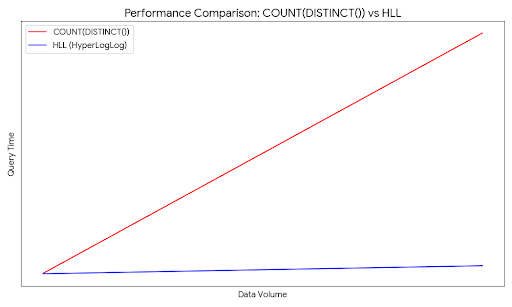

Note: actually the graphs are with an exponantial slope, but they are linear here, for the sack of intuition and simplicity

In [68]:
@bigquery_job_param
def precise_median():
  return f"""
          SELECT
          'Precise Median' AS method,
            PERCENTILE_CONT(sale_price, 0.5) OVER() AS median_sales_price,
            FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.order_items`
            WHERE status = 'Complete' ; """

precise_median = precise_median()
precise_m = precise_median['median_sales_price'].iloc[0]
precise_median.head()


--- Job Execution Details ---
**Wall Time (Function):** 0.22 seconds
**Data Processed:** 0.00 GB
**Slot-Time Consumed:** 0.0001 slot-hours
**Result Served from Cache:** False
-----------------------------------



,method,median_sales_price
0,Precise Median,39.990002
1,Precise Median,39.990002
2,Precise Median,39.990002
3,Precise Median,39.990002
4,Precise Median,39.990002


In [69]:
@bigquery_job_param
def approx_median():
    return f"""
            SELECT
              'Approximate Median' AS method,
              APPROX_QUANTILES(sale_price, 100)[OFFSET(50)] as median_sales_price
            FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.order_items`
            WHERE status = 'Complete' ; """


approx_median = approx_median()
approx_m = approx_median['median_sales_price'].iloc[0]
approx_median.head()


--- Job Execution Details ---
**Wall Time (Function):** 0.09 seconds
**Data Processed:** 0.00 GB
**Slot-Time Consumed:** 0.0000 slot-hours
**Result Served from Cache:** False
-----------------------------------



,method,median_sales_price
0,Approximate Median,39.990002


In [70]:
@bigquery_job_param
def kll_median():
    return f"""
            SELECT
              'KLL Sketch' AS method,
              KLL_QUANTILES.EXTRACT_FLOAT64(
                KLL_QUANTILES.INIT_FLOAT64(sale_price, 100), 2
              )[OFFSET(1)] as median_sales_price
            FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.order_items`
            WHERE status = 'Complete'; """


kll_median = kll_median()
kll_m = kll_median['median_sales_price'].iloc[0]
kll_median.head()


--- Job Execution Details ---
**Wall Time (Function):** 0.15 seconds
**Data Processed:** 0.00 GB
**Slot-Time Consumed:** 0.0000 slot-hours
**Result Served from Cache:** False
-----------------------------------



,method,median_sales_price
0,KLL Sketch,39.990002


In [71]:
summary_data = [
    {
        'Method': 'Precise Median',
        'Distinct Sessions': precise_m,
        'Error Rate': 0.0
    },
    {
        'Method': 'Approximate Median',
        'Distinct Sessions': approx_m,
        'Error Rate': abs(approx_m - precise_m) / precise_m
    },
    {
        'Method': 'KLL Sketch',
        'Distinct Sessions': kll_m,
        'Error Rate': abs(kll_m - precise_m) / precise_m
    }
]

df_summary = pd.DataFrame(summary_data)
df_summary['Distinct Sessions'] = df_summary['Distinct Sessions'].apply(lambda x: "{:,.0f}".format(x))
df_summary['Error Rate'] = df_summary['Error Rate'].apply(lambda x: "{:.4%}".format(x))
display(df_summary)

,Method,Distinct Sessions,Error Rate
0,Precise Median,40,0.0000%
1,Approximate Median,40,0.0000%
2,KLL Sketch,40,0.0000%


**Architectural Implication:**
The APPROX_COUNT_DISTINCT is a great optimization. But the real power is the composable nature of HLL_COUNT.INIT and HLL_COUNT.MERGE.
Imagine this: we run a single daily job to calculate HLL_COUNT.INIT(session_id) AS hll_sketch grouped by date, browser, and traffic_source. We store just these tiny sketches in a new table.
Our "live" dashboard can then SELECT HLL_COUNT.MERGE(hll_sketch) for any combination of filters (e.g., 'last 7 days', 'Chrome') in milliseconds. It queries a tiny, pre-aggregated table instead of the petabyte-scale raw event table. This is the architectural pattern for building sub-second BI on massive-scale data.

**Links to documentation:**


*   Data Sketches: https://datasketches.apache.org/
*   Major Sketches Families: https://datasketches.apache.org/docs/Architecture/MajorSketchFamilies.html
*   Sketches in BigQuery: https://docs.cloud.google.com/bigquery/docs/sketches
*  Apache DataSketches in BigQuery: https://cloud.google.com/blog/products/data-analytics/bigquery-supports-apache-datasketches-for-approximate-analytics?e=48754805
* Apache DataSketches Theta Sketches for Google BigQuery: https://github.com/apache/datasketches-bigquery/blob/main/theta/README.md


## 3. Advanced Business Logic



### Match Recognize

In [72]:
match_recognize = f"""
SELECT
  session_id,
  funnel_start_time,
  event_sequence
FROM
  `{PROJECT_ID}.{STAGING_DATASET_ID}.events` AS T
  MATCH_RECOGNIZE (
    PARTITION BY session_id
    ORDER BY created_at

    MEASURES
      FIRST(created_at) AS funnel_start_time,
      ARRAY_AGG(event_type) AS event_sequence

    PATTERN (VIEW_PRODUCT+ ADD_TO_CART* PURCHASE)

    DEFINE
      VIEW_PRODUCT AS T.event_type = 'product',
      ADD_TO_CART  AS T.event_type = 'cart',
      PURCHASE     AS T.event_type = 'purchase'
  )

"""

df = client.query(match_recognize).to_dataframe()
display(df)


,session_id,funnel_start_time,event_sequence
0,0005191b-0cc3-4c58-bbf3-cf57d84d80fa,2023-09-12 15:15:43+00:00,"[product, cart, purchase]"
1,00134b55-9c8a-4b41-a322-7ec1e2e407a0,2024-12-13 21:52:09+00:00,"[product, cart, purchase]"
2,0018f8b2-f9f1-4d81-ade5-10f9e6e2caae,2024-05-17 14:41:56+00:00,"[product, cart, purchase]"
3,00194839-0482-41e3-8657-f33b39ac67b8,2025-02-05 22:28:10+00:00,"[product, cart, purchase]"
4,001b1850-669e-4a6d-92a0-a2f43bfa3d86,2024-09-20 12:10:05+00:00,"[product, cart, purchase]"
...,...,...,...
180412,ffebc2d6-a94c-4376-ab99-4f96cf5e64c2,2025-08-03 12:53:39+00:00,"[product, cart, purchase]"
180413,fff0aaf6-00f5-403d-b1e4-744e900c021b,2024-11-03 07:12:01+00:00,"[product, cart, purchase]"
180414,fff9ef2c-2a34-4047-8c48-5f1be74bf690,2024-04-14 12:09:36+00:00,"[product, cart, purchase]"
180415,fffe222d-bcff-491b-9005-82b520a3970d,2025-04-10 06:18:14+00:00,"[product, cart, purchase]"


**Architectural Implication:**
This is a task that was previously impossible with standard SQL. We are now performing stateful, sequential pattern matching directly in our warehouse. This unlocks an entirely new class of analysis for fraud detection (e.g., finding a pattern of (SMALL_DEPOSIT+ LARGE_WITHDRAWAL)) 38, log analysis, and churn prediction etc.

**Links to documentation:**


*   MATCH_RECOGNIZE() in BigQuery: https://cloud.google.com/blog/products/data-analytics/introducing-match_recognize-in-bigquery
*   MATCH_RECOGNIZE() syntax: https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/query-syntax#match_recognize_clause

### Multi Dimensional Grouping

In [73]:
multi_dim_grp = f"""
SELECT
  CASE
    WHEN GROUPING(department) = 0 AND GROUPING(category) = 0 THEN 'Department & Category Subtotal'
    WHEN GROUPING(department) = 0 THEN 'Department Total'
    WHEN GROUPING(category) = 0 THEN 'Category Total'
    WHEN GROUPING(brand) = 0 THEN 'Brand Total'
    ELSE 'Gand Total'
  END AS Aggregation_Level,
  department,
  category,
  brand,
  SUM(sale_price) AS Total_Amount
FROM
  `{PROJECT_ID}.{STAGING_DATASET_ID}.products` AS p
JOIN
  `{PROJECT_ID}.{STAGING_DATASET_ID}.order_items` AS oi
ON
  oi.product_id = p.id
GROUP BY
GROUPING SETS
  ( (department),
    (category),
    (brand),
    (department, category),
    () )
ORDER BY
  department,
  category,
  brand;
"""

df = client.query(multi_dim_grp).to_dataframe()
display(df)

,Aggregation_Level,department,category,brand,Total_Amount
0,Gand Total,None,None,None,1.077654e+07
1,Brand Total,None,None,None,5.643370e+03
2,Brand Total,None,None,!it Jeans,3.582590e+03
3,Brand Total,None,None,'47 Brand,2.760000e+02
4,Brand Total,None,None,007Lingerie,1.810800e+02
...,...,...,...,...,...
2813,Department & Category Subtotal,Women,Socks & Hosiery,None,6.417765e+04
2814,Department & Category Subtotal,Women,Suits,None,1.260335e+05
2815,Department & Category Subtotal,Women,Sweaters,None,2.915262e+05
2816,Department & Category Subtotal,Women,Swim,None,3.237828e+05


**Architectural Implication:**
We are moving the "pivot table" logic into the database. This means the BI tool (like Looker Studio or Tableau) gets a perfectly pre-aggregated, clean dataset. The business logic is centralized, testable, and reusable, rather than being scattered across dozens of fragile dashboard definitions

**Links to documentation:**


*   Beyound Group by: https://cloud.google.com/blog/products/data-analytics/bigquery-advanced-aggregation-functions
*   GROUPING() syntax: https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/aggregate_functions#grouping
* Google BigQuery now supports cubes: https://medium.com/codex/google-bigquery-now-supports-cubes-e50ecd39e447

### Reusable Logic

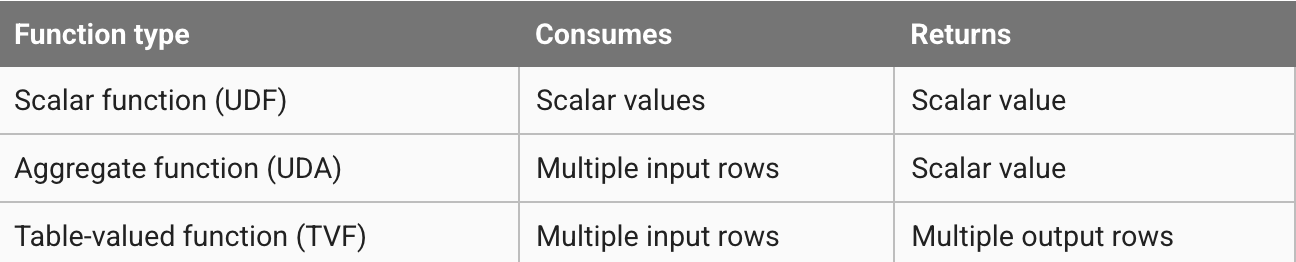

User Defined Functions (UDF)



In [74]:
udf_create = f"""
CREATE FUNCTION IF NOT EXISTS {STAGING_DATASET_ID}.CalculateTaxDeduction(
    sale_price FLOAT64,
    category STRING,
    user_country STRING
)
RETURNS FLOAT64
AS ((
  WITH Rules AS (
    SELECT
      UPPER(user_country) as country_code,
      LOWER(category) as cat_norm,
      COALESCE(sale_price, 0) as price
  )
  SELECT
    ROUND(
      (Rules.price * CASE Rules.country_code
          WHEN 'United States' THEN 0.07
          WHEN 'Brasil' THEN 0.20
          WHEN 'Japan' THEN 0.19
          WHEN 'Spain' THEN 0.10
          ELSE 0.15
        END)
      +
      (Rules.price * CASE
          WHEN Rules.cat_norm LIKE '%Accessories%' THEN 0.05
          WHEN Rules.cat_norm LIKE '%Swim%' THEN 0.12
          WHEN Rules.cat_norm LIKE '%Jeans%' THEN 0.02
          ELSE 0.0
        END)
      +
      (CASE
          WHEN Rules.country_code = 'USA' AND Rules.cat_norm = 'Jeans' THEN 5.00
          WHEN Rules.country_code = 'Japan' AND Rules.cat_norm LIKE '%Accessories%' THEN 2.50
          ELSE 0.0
        END),
    2)
  FROM Rules
));
"""

job = client.query(udf_create)
job.result()
print("UDF created")

UDF created


**Links to documentation:**


*   User Defined Functions: https://docs.cloud.google.com/bigquery/docs/user-defined-functions
*   Python User Defined Functions: https://docs.cloud.google.com/bigquery/docs/user-defined-functions-python
* Exploring BigQuery: UDF: https://nadiaslnv.medium.com/exploring-bigquery-udf-user-defined-function-b4f2c9091131

User Defined Aggregated Functions (UDAF)

In [75]:
udaf_create = f"""
CREATE AGGREGATE FUNCTION IF NOT EXISTS {STAGING_DATASET_ID}.AverageOrderValue(
    sale_price FLOAT64,
    order_id INT64
)
RETURNS FLOAT64
AS (
  -- Total Revenue / Total Unique Orders
  SUM(sale_price) / NULLIF(COUNT(DISTINCT order_id), 0)
);

"""

job = client.query(udaf_create)
job.result()
print("UDAF created")

UDAF created


**Links to documentation:**


*   User Defined Aggregate Functions: https://docs.cloud.google.com/bigquery/docs/user-defined-aggregates#create-sql-udaf

Table Valued Function (TVF)


In [76]:
tvf_create = f"""
CREATE TABLE FUNCTION IF NOT EXISTS {STAGING_DATASET_ID}.SalesByCountry(
  country_name STRING,
  curr_date DATE
)
AS (
  SELECT
    u.id,
    u.country,
    oi.order_id,
    p.category,
    SUM(oi.sale_price) AS total_sales
  FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.order_items` AS oi
  JOIN `{PROJECT_ID}.{STAGING_DATASET_ID}.users` AS u ON oi.user_id = u.id
  JOIN `{PROJECT_ID}.{STAGING_DATASET_ID}.products` AS p ON oi.product_id = p.id
  WHERE u.country = country_name AND DATE(oi.created_at) = curr_date
  GROUP BY ALL
);
"""

job = client.query(tvf_create)
job.result()
print("TVF created")

TVF created


**Links to documentation:**


*   Table Functions (TVF): https://docs.cloud.google.com/bigquery/docs/table-functions

Putting it All Together

In [77]:
run_workflow = f"""
SELECT
    t.category,
    SUM(t.total_sales) AS gross_revenue,
    SUM(
      {STAGING_DATASET_ID}.CalculateTaxDeduction(t.total_sales, t.category, t.country)
    ) AS UDF_total_tax_deduction,
    {STAGING_DATASET_ID}.AverageOrderValue(t.total_sales, t.order_id) AS UDAF_average_order_value,
    COUNT(DISTINCT t.order_id) as total_orders
FROM
    {STAGING_DATASET_ID}.SalesByCountry('Brasil', DATE('2024-01-04')) AS t

GROUP BY
    t.category
ORDER BY
    gross_revenue DESC;
"""

df = client.query(run_workflow).to_dataframe()
display(df)

,category,gross_revenue,UDF_total_tax_deduction,UDAF_average_order_value,total_orders
0,Pants,129.979996,19.50,64.989998,2
1,Jeans,115.370003,17.31,57.685001,2
2,Shorts,79.000000,11.85,79.000000,1
3,Pants & Capris,78.000000,11.70,78.000000,1
4,Tops & Tees,42.950001,6.44,21.475000,2
5,Active,23.230000,3.48,23.230000,1
6,Underwear,19.200001,2.88,19.200001,1
7,Leggings,10.990000,1.65,10.990000,1


**Architectural Implication:**
This is "Software Engineering for SQL." We are creating a robust, testable, and maintainable API layer for our data. By encapsulating logic in UDFs, UDAFs, and TVFs, we ensure that everyone in the company uses the same definitions for key metrics, eliminating "report-vs-report" arguments.

## 4. AI Analytics

### Setup reviews table

In [78]:
generate_reviews = f"""
CREATE TABLE IF NOT EXISTS `{PROJECT_ID}.{STAGING_DATASET_ID}.order_reviews` AS
WITH labeled_data AS (
  SELECT
    oi.order_id,
    p.name AS product_name,
    COALESCE(p.description, p.name) AS description,
    RAND() AS sentiment_roll,
    RAND() AS topic_roll
  FROM `{PROJECT_ID}.{STAGING_DATASET_ID}.order_items` AS oi
  JOIN `{PROJECT_ID}.{STAGING_DATASET_ID}.products` AS p
    ON oi.product_id = p.id
)

SELECT
  order_id,
  product_name,
  AI.GENERATE(
    CONCAT(
      "Generate a customer review for this product. ",
      CASE
        WHEN sentiment_roll <= 0.90 THEN "The sentiment must be highly positive and enthusiastic (5 stars). "
        ELSE "The sentiment must be critical and disappointed (1 star). "
      END,
      CASE
        WHEN topic_roll <= 0.25 THEN "Mention the fast shipping and secure packaging. "
        WHEN topic_roll <= 0.50 THEN "Discuss the billing process and value for money. "
        WHEN topic_roll <= 0.75 THEN "Focus on the high product quality and materials. "
        ELSE "Describe why this makes a perfect gift for someone. "
      END,

      "Base the review on this description: ", description
    )
  ).result AS generated_review

FROM labeled_data
"""

job = client.query(generate_reviews)
job.result()
print("user reviews were generated")

user reviews were generated


Filtering using AI.IF()

In [79]:
ai_filter = f"""
SELECT
  *
FROM
  {PROJECT_ID}.{STAGING_DATASET_ID}.order_reviews
WHERE
  AI.IF((
    'does the review mention gift?',
    generated_review),
    connection_id => 'projects/{PROJECT_NUM}/locations/{LOCATION}/connections/{CONNECTION_NAME}'
  )
LIMIT 10;
"""

df = client.query(ai_filter).to_dataframe()
display(df)

,order_id,product_name,generated_review
0,62018,!iT Jeans Women's Bonaroo Slouch Shorts,⭐⭐⭐⭐⭐ **OBSESSED! The BEST Shorts EVER - Perfe...
1,23218,!iT Jeans Women's Skinny Micro Printed Corduroy,⭐⭐⭐⭐⭐ **Absolutely IN LOVE with these Jeans! P...
2,119291,#5098 Satin V-neck Bridemaid Prom Formal Long ...,⭐⭐⭐⭐⭐ **Absolutely STUNNING! THE PERFECT Gift!...
3,46801,#5098 Satin V-neck Bridemaid Prom Formal Long ...,⭐⭐⭐⭐⭐ **Absolutely STUNNING! The Perfect Gift ...
4,10371,'Sexy Legs' Floral Print Fashion Leggings,"**One Star - These are the PERFECT ""I Don't Li..."
5,8677,(2384) Fishtail Flute Skirt with Free Skinny B...,⭐⭐⭐⭐⭐ **Absolutely STUNNING! The Perfect Gift ...
6,62135,(2384) Fishtail Peplum Hem Pencil Skirt Black,**One Star - The PERFECT Gift...for Your Nemes...
7,98203,(6249-3) Teddy Style Function Suit with Pencil...,⭐⭐⭐⭐⭐ **Absolutely Obsessed! The PERFECT Gift ...
8,104711,(CH133NM) A Medium Full Bridal Petticoat Crino...,⭐⭐⭐⭐⭐ **This Crinoline is a Dream Come True an...
9,76140,1-Pair JMS Comfort Top Legging Hosiery 89003 4...,⭐⭐⭐⭐⭐ **HOLY GRAIL LEGGINGS! THE PERFECT GIFT ...


### Rank using AI.SCORE()

In [ ]:
ai_rate = f"""
SELECT
  *,
  AI.SCORE((
    'how negative is the sentiment of this review?',generated_review),
    connection_id => 'projects/{PROJECT_NUM}/locations/{LOCATION}/connections/{CONNECTION_NAME}'
  ) AS negativity_score
FROM
  `{PROJECT_ID}.{STAGING_DATASET_ID}.order_reviews`
ORDER BY
  negativity_score DESC
LIMIT 10;
"""

df = client.query(ai_rate).to_dataframe()
display(df)

### Categorize using AI.CLASSIFY()

In [ ]:
ai_ctg = f"""
SELECT
  AI.CLASSIFY(
    generated_review,
    categories => ['Billing', 'Shipping', 'Product Quality', 'Other'],
    connection_id => 'projects/{PROJECT_NUM}/locations/{LOCATION}/connections/{CONNECTION_NAME}'
  ) AS category,
  COUNT(1) AS reviews_count
FROM
  `{PROJECT_ID}.{STAGING_DATASET_ID}.order_reviews`
GROUP BY
  category;
"""

df = client.query(ai_ctg).to_dataframe()
display(df)

**Architectural Implication:**
This is the democratization of AI. We have just performed generative AI content creation, filtering unstructured data, sentiment analysis, and categorizing unstructured data.
The AI.IF function is particularly revolutionary. It's not a batch job; it's a scalar function that can be used in a WHERE, JOIN, or GROUP BY clause. For the first time, analysts can interact with unstructured data at scale based on its meaning, not just its string content.

**Links to documentation:**


*   AI.IF(): https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/bigqueryml-syntax-ai-if
*   AI.SCORE(): https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/bigqueryml-syntax-ai-score
* AI.CLASSIFY(): http://docs.cloud.google.com/bigquery/docs/reference/standard-sql/bigqueryml-syntax-ai-classify



# **###Bonus###**

### CDC Monitoring

In [ ]:
apply_cdc = f"""
ALTER TABLE `{PROJECT_ID}.{STAGING_DATASET_ID}.order_items`
SET OPTIONS (enable_change_history = TRUE);
"""

job = client.query(apply_cdc)
job.result()
print("changes metadata added to the table")

In [ ]:
update_records_testing = f"""
UPDATE `{PROJECT_ID}.{STAGING_DATASET_ID}.order_items`
SET sale_price = sale_price + 1
WHERE MOD(product_id,3) = 0;
"""

job = client.query(update_records_testing)
job.result()
print("testing cdc applied on the data")

In [ ]:
test_cdc = f"""
SELECT
  product_id,
  sale_price,
  _CHANGE_TYPE AS change_type,
  _CHANGE_TIMESTAMP AS change_time
FROM
  CHANGES(TABLE `{PROJECT_ID}.{STAGING_DATASET_ID}.order_items`, NULL, TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 60 SECOND))
ORDER BY product_id, sale_price;
"""

df = client.query(test_cdc).to_dataframe()
display(df)

**Architectural Implication:**
This is a monumental simplification of the data stack. We've just enabled real-time, event-driven architectures using a single SQL function. The "warehouse" is now an auditable, streaming-aware source of truth, and we can build downstream alerting systems or real-time materialized views directly on top of this change feed.


**Links to documentation:**


* Stream table updates with change data capture: https://docs.cloud.google.com/bigquery/docs/change-data-capture
* CHANGES() function: https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/time-series-functions#changes
*   Work with change history: https://docs.cloud.google.com/bigquery/docs/change-history

*Note: Don't forget to set enable_change_history = TRUE*

## Cleanup Resources

In [ ]:
def cleanup_demo_resources():

    datasets_to_delete = [STAGING_DATASET_ID, RAW_DATASET_ID]

    for ds_id in datasets_to_delete:
        ds_ref = f"{PROJECT_ID}.{ds_id}"
        try:
            client.delete_dataset(ds_ref, delete_contents=True, not_found_ok=True)
            print(f" Deleted dataset: {ds_id}")
        except Exception as e:
            print(f"Error deleting {ds_id}: {e}")

    conn_client = bq_connection.ConnectionServiceClient()
    path = conn_client.connection_path(PROJECT_ID, LOCATION, CONNECTION_NAME)
    try:
      conn_client.delete_connection(name=path)
      print(f"Deleted connection: {CONNECTION_NAME}")
    except Exception as e:
      print(f"Error deleting connection: {e}")

    print("Resources Cleanup Complete.")

cleanup_demo_resources()